In [1]:
!git clone https://github.com/dannasalazar11/Msc_thesis.git

import sys
sys.path.append('/kaggle/working/Msc_thesis')

from gmrrnet_adhd.utils import get_segmented_data
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('float32')


import tensorflow as tf
import numpy as np
import random
import os

# Establecer semilla
seed = 42

# Semillas para módulos principales
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

Cloning into 'Msc_thesis'...
remote: Enumerating objects: 455, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 455 (delta 14), reused 0 (delta 0), pack-reused 427 (from 1)
Receiving objects: 100% (455/455), 49.98 MiB | 21.22 MiB/s, done.
Resolving deltas: 100% (291/291), done.


2025-07-03 14:51:12.070166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751554272.267160      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751554272.325226      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Importación de base de datos

In [2]:
X, y, sbjs = get_segmented_data()
X.shape, y.shape, len(sbjs)

((8213, 19, 512), (8213, 2), 8213)

# Importación de folds

In [3]:
import os

import pickle

with open("/kaggle/input/ieee-tdah-control-database/folds.pkl", "rb") as f:
    folds = pickle.load(f)

# **Creación del modelo**

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Conv2D, Concatenate, Input, Reshape, Flatten, Dense, Dropout, Activation, LayerNormalization, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.losses import Loss
from keras_nlp.layers import TransformerEncoder
from keras.saving import register_keras_serializable

## Loss

In [5]:
class NormalizedBinaryCrossentropy(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_true: (batch_size, 2), one-hot encoded
        y_pred: (batch_size, 2), probabilities
        """
        # Loss for true label
        true_loss = tf.keras.losses.categorical_crossentropy(y_true, y_pred)

        # Create one-hot vectors for each class (assuming binary)
        left = tf.tile([[1.0, 0.0]], [tf.shape(y_pred)[0], 1])
        right = tf.tile([[0.0, 1.0]], [tf.shape(y_pred)[0], 1])

        # Loss for each possible label
        loss_left = tf.keras.losses.categorical_crossentropy(left, y_pred)
        loss_right = tf.keras.losses.categorical_crossentropy(right, y_pred)

        # Normalized loss        
        cce_norm = tf.divide(true_loss, (loss_left + loss_right))
        
        return cce_norm

class RenyiMutualInformation(Loss):
    def __init__(self, C, **kwargs):
        self.C = C
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_pred: Tensor de tamaño (N, G+1): G entropías marginales + 1 entropía conjunta
        """
        
        G = y_pred.shape[1]-1
        entropy,  joint_entropy = tf.split(y_pred, [G,1], axis=-1)
        
        #Cast todo
        entropy = tf.cast(entropy, tf.float64)
        joint_entropy = tf.cast(joint_entropy, tf.float64)
        log_C = tf.math.log(tf.cast(self.C, tf.float64))
        
        mutual_information = (tf.expand_dims(tf.reduce_sum(entropy, axis=-1), axis=-1) - joint_entropy) / (G * log_C)


        return tf.nn.relu(mutual_information)

class KL_divergence(Loss):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, y_true, y_pred):
        """
        y_true: 
        y_pred: z_mean, z_log_var ambos de tamaño N x latent_dim
        """
    
        latent_dim = tf.shape(y_pred)[-1] // 2
        z_mean = y_pred[..., :latent_dim]
        z_log_var = y_pred[..., latent_dim:]
        
        loss =  -0.5 * tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)

        return loss

## Capas personalizadas

In [6]:
class GaussianKernelLayer(Layer):
    def __init__(self, **kwargs):
        super(GaussianKernelLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        # No es necesario agregar sigma como un peso aquí
        super(GaussianKernelLayer, self).build(input_shape)

    def call(self, inputs):
        # inputs ahora será una lista o tupla: [x, sigma]
        x, sigma = inputs  # Asumimos que sigma viene como entrada junto con los datos
        
        # inputs shape: (N, C, T, F)
        N, C, T, F = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        
        # Reshape the input to (N*F, C, T)
        x = tf.transpose(x, perm=(0,3,1,2))  # (N,F,C,T)
        x_reshaped = tf.reshape(x, (N*F, C, T))
        
        # Calculate the pairwise squared Euclidean distance
        squared_differences = tf.expand_dims(x_reshaped, axis=2) - tf.expand_dims(x_reshaped, axis=1)  # (N*F,C,C,T)
        squared_differences = tf.square(squared_differences)  # (N*F,C,C,T)
        pairwise_distances_squared = tf.reduce_sum(squared_differences, axis=-1)  # (N*F,C,C)
        pairwise_distances_squared = tf.reshape(pairwise_distances_squared, (N, F, C, C))  # (N,F,C,C)
        pairwise_distances_squared = tf.transpose(pairwise_distances_squared, perm=(0,2,3,1))  # (N,C,C,F)
        
        # Calculate the Gaussian kernel using the provided sigma
        gaussian_kernel = tf.exp(-pairwise_distances_squared / (2.0 * tf.square(sigma)))
        
        return gaussian_kernel


def inception_block(x, F, num_kernels):
    kernels = []
    branches = []

    # Genera las ramas y almacénalas en la lista
    for i in range(1, num_kernels + 1):
        name = "gaussian_layer_" + str(i)
        sigma = 5/(2**(i-1))
        branch_k = GaussianKernelLayer(name=name)([x,tf.convert_to_tensor(sigma, dtype=tf.float32)])
        branch = Conv2D(F, (3, 3), padding='same', activation='relu')(branch_k)
        kernels.append(branch_k)
        branches.append(branch)

    # Concatenar todas las ramas usando Concatenate con axis=-1
    concatenated_kernels = Concatenate(axis=-1)(kernels)
    inception = Concatenate(axis=-1)(branches)
    return concatenated_kernels, inception


class RenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha=2, **kwargs):
        super(RenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: NxF
        """
        C = tf.shape(K)[-1]

        # Crear una máscara para obtener los elementos diagonales
        diag = tf.linalg.diag_part(K)
        # Calcular el producto de los elementos diagonales
        denominator = tf.math.sqrt(tf.linalg.matmul(tf.expand_dims(diag, -1), tf.expand_dims(diag, -1), transpose_b=True))
        
        # Normalización
        X = tf.cast((1 / C), tf.float32) * tf.math.divide(K, denominator)

        if self.alpha == 2:
            # Realiza el producto matricial entre las dos últimas dimensiones
            X_matmul = tf.linalg.matmul(X, X)
            return -tf.math.log(tf.linalg.trace(X_matmul))
        else:
            # Calcula los autovalores y autovectores de las dos últimas dimensiones
            e, _ = tf.linalg.eigh(X)
            # Calcula la entropía de Renyi
            return (tf.math.log(tf.reduce_sum(tf.math.real(tf.math.pow(e, self.alpha)), axis=-1)) / (1 - self.alpha))


class JointRenyiEntropyLayer(tf.keras.layers.Layer):
    def __init__(self, alpha, **kwargs):
        super(JointRenyiEntropyLayer, self).__init__(**kwargs)
        self.alpha = alpha
        self.renyi_entropy_layer = RenyiEntropyLayer(alpha)

    def call(self, K):
        """
        input: K tensor, (N, F, C, C)
        output: Nx1
        """
        C = tf.shape(K)[-1]
        product = tf.reduce_prod(K, axis=1)  # (N, C, C)

        trace = tf.linalg.trace(product)
        trace = tf.expand_dims(tf.expand_dims(trace, axis=-1), axis=-1)
        trace = tf.tile(trace, [1, C, C])

        argument = product / trace
        argument = tf.expand_dims(argument, axis=1)  # Necesario porque renyi_entropy recibe 4 dimensiones (1, C, C)
        
        joint_entropy = self.renyi_entropy_layer(argument)  # Llamada a la capa de entropía de Renyi
        return joint_entropy

class UpperTriangularFlatten(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        """
        inputs: (N, G, C, C)
        output: (N, G * num_upper_tri)
        """
        shape = tf.shape(inputs)
        N, G, C = shape[0], shape[1], shape[2]

        # Reshape a (N*G, C, C)
        reshaped = tf.reshape(inputs, [N * G, C, C])

        # Get upper triangular mask
        mask = tf.linalg.band_part(tf.ones((C, C), dtype=tf.bool), 0, -1)
        flat = tf.reshape(reshaped, [N * G, -1])  # (N*G, C*C)
        mask_flat = tf.reshape(mask, [-1])        # (C*C,)

        # Apply mask
        upper_tri_flat = tf.boolean_mask(flat, mask_flat, axis=1)  # (N*G, num_upper_tri)

        # Reshape to (N, G * num_upper_tri)
        num_upper_tri = (C * (C + 1)) // 2
        output = tf.reshape(upper_tri_flat, [N, G * num_upper_tri])

        return output

    def compute_output_shape(self, input_shape):
        N, G, C, _ = input_shape
        num_upper_tri = (C * (C + 1)) // 2
        return (N, G * num_upper_tri)

class TransposeLayer(Layer):
    def call(self, x):
        return tf.transpose(x, perm = (0,3,1,2))

## **Modelo propuesto**

In [7]:
def GMRRNet(num_kernels=3, nb_classes=2, Chans=19, Samples=512, 
                                       norm_rate=0.25, alpha=2, num_heads=3, latent_dim=64):
    
    input1 = Input(shape=(Chans, Samples))

    # 1 Reorganize data for Transformer (Samples, Chans)
    x = Reshape((Samples, Chans))(input1)

    # 2 Normalización antes del Transformer
    x = LayerNormalization()(x)

    # 3 Apply TransformerEncoder
    transformer_encoder = TransformerEncoder(num_heads=num_heads, intermediate_dim=128) # =>  (T, C)
    x = transformer_encoder(x)

    # 4 Normalización después del Transformer
    x = LayerNormalization()(x)

    # 5 Restore original shape (Chans, Samples, 1)
    x = Reshape((Chans, Samples, 1))(x)
    
    # 6 Inception with KernelConv
    concatenated_branches, inception = inception_block(x, 5, num_kernels)                        # => (N, C, C, G)
    concatenated_branches = TransposeLayer(name="concatenated_branches")(concatenated_branches)  # => (N, G, C, C)

    ##### Para LOSS KL ################

    faltten_connectivities = UpperTriangularFlatten(name="upper_triangular_flatten")(concatenated_branches)
    latent_space = Dense(latent_dim, activation='relu', name="latent_space")(faltten_connectivities)
    z_mean = Dense(latent_dim, name="z_mean")(latent_space)  
    z_log_var = Dense(latent_dim,name="z_log_var")(latent_space)
    z_concat = tf.keras.layers.Concatenate(name="kl_output")([z_mean, z_log_var])

    ############################
    
    # 7 Renyi entropies
    layer_entropy = RenyiEntropyLayer(alpha=alpha)(concatenated_branches)
    layer_joint_entropy = JointRenyiEntropyLayer(alpha=alpha)(concatenated_branches)
    entropies_out = Concatenate(axis=-1, name='entropy_output')([
        layer_entropy, layer_joint_entropy
    ])
    
    # 8 Extra convolutional stack
    final_conv = Conv2D(3, kernel_size=3, padding='same', activation='relu', name='Conv2D_2')(inception)
    final_conv = BatchNormalization()(final_conv)
    
    final_conv = Conv2D(3, kernel_size=3, padding='same', activation='relu', name='Conv2D_3')(final_conv)
    final_conv = BatchNormalization()(final_conv)
    
    flat = Flatten()(final_conv)
    concat = Concatenate(name="merge_with_z")( [flat, z_concat] )
    drop = Dropout(0.2)(concat)
    dense = Dense(nb_classes, name='output', kernel_constraint=max_norm(norm_rate))(drop)
    softmax = Activation('softmax', name='classification_output')(dense)
    
    model = Model(inputs=input1, outputs=[softmax, entropies_out, z_concat, concatenated_branches])
    
    return model

In [8]:
num_kernels = 3
num_heads = 2
norm_rate = 0.05

lambda_1 = 0.6
lambda_2 = 0.0

lambda_3 = 0.08

# Definir los argumentos del modelo
model_args = {
    'num_kernels': num_kernels,
    'nb_classes': 2,
    'Chans': 19,
    'Samples': 512,
    'norm_rate': norm_rate,
    'alpha': 2,
    'num_heads': num_heads,
    'latent_dim': 64
}

model = GMRRNet(**model_args)
model.summary()

I0000 00:00:1751554289.247628      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 19, 512)        │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 512, 19)        │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 512, 19)        │             38 │ reshape[0][0]          │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ transformer_encoder       │ (None, 512, 19)        │          6,528 │ layer_normalization[0… │
│ (TransformerEncoder)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 512, 19)        │             38 │ transformer_encoder[0… │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape_1 (Reshape)       │ (None, 19, 512, 1)     │              0 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gaussian_layer_1          │ (None, 19, 19, 1)      │              0 │ reshape_1[0][0]        │
│ (GaussianKernelLayer)     │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gaussian_layer_2          │ (None, 19, 19, 1)      │              0 │ reshape_1[0][0]        │
│ (GaussianKernelLayer)     │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ gaussian_layer_3          │ (None, 19, 19, 1)      │              0 │ reshape_1[0][0]        │
│ (GaussianKernelLayer)     │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 19, 19, 5)      │             50 │ gaussian_layer_1[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 19, 19, 5)      │             50 │ gaussian_layer_2[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 19, 19, 5)      │             50 │ gaussian_layer_3[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 19, 19, 15)     │              0 │ conv2d[0][0],          │
│ (Concatenate)             │                        │                │ conv2d_1[0][0],        │
│                           │                        │                │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 19, 19, 3)      │              0 │ gaussian_layer_1[0][0… │
│                           │                        │                │ gaussian_layer_2[0][0… │
│                           │                        │                │ gaussian_layer_3[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv2D_2 (Conv2D)    

 Total params: 54,558 (213.12 KB)

 Trainable params: 54,546 (213.07 KB)

 Non-trainable params: 12 (48.00 B)

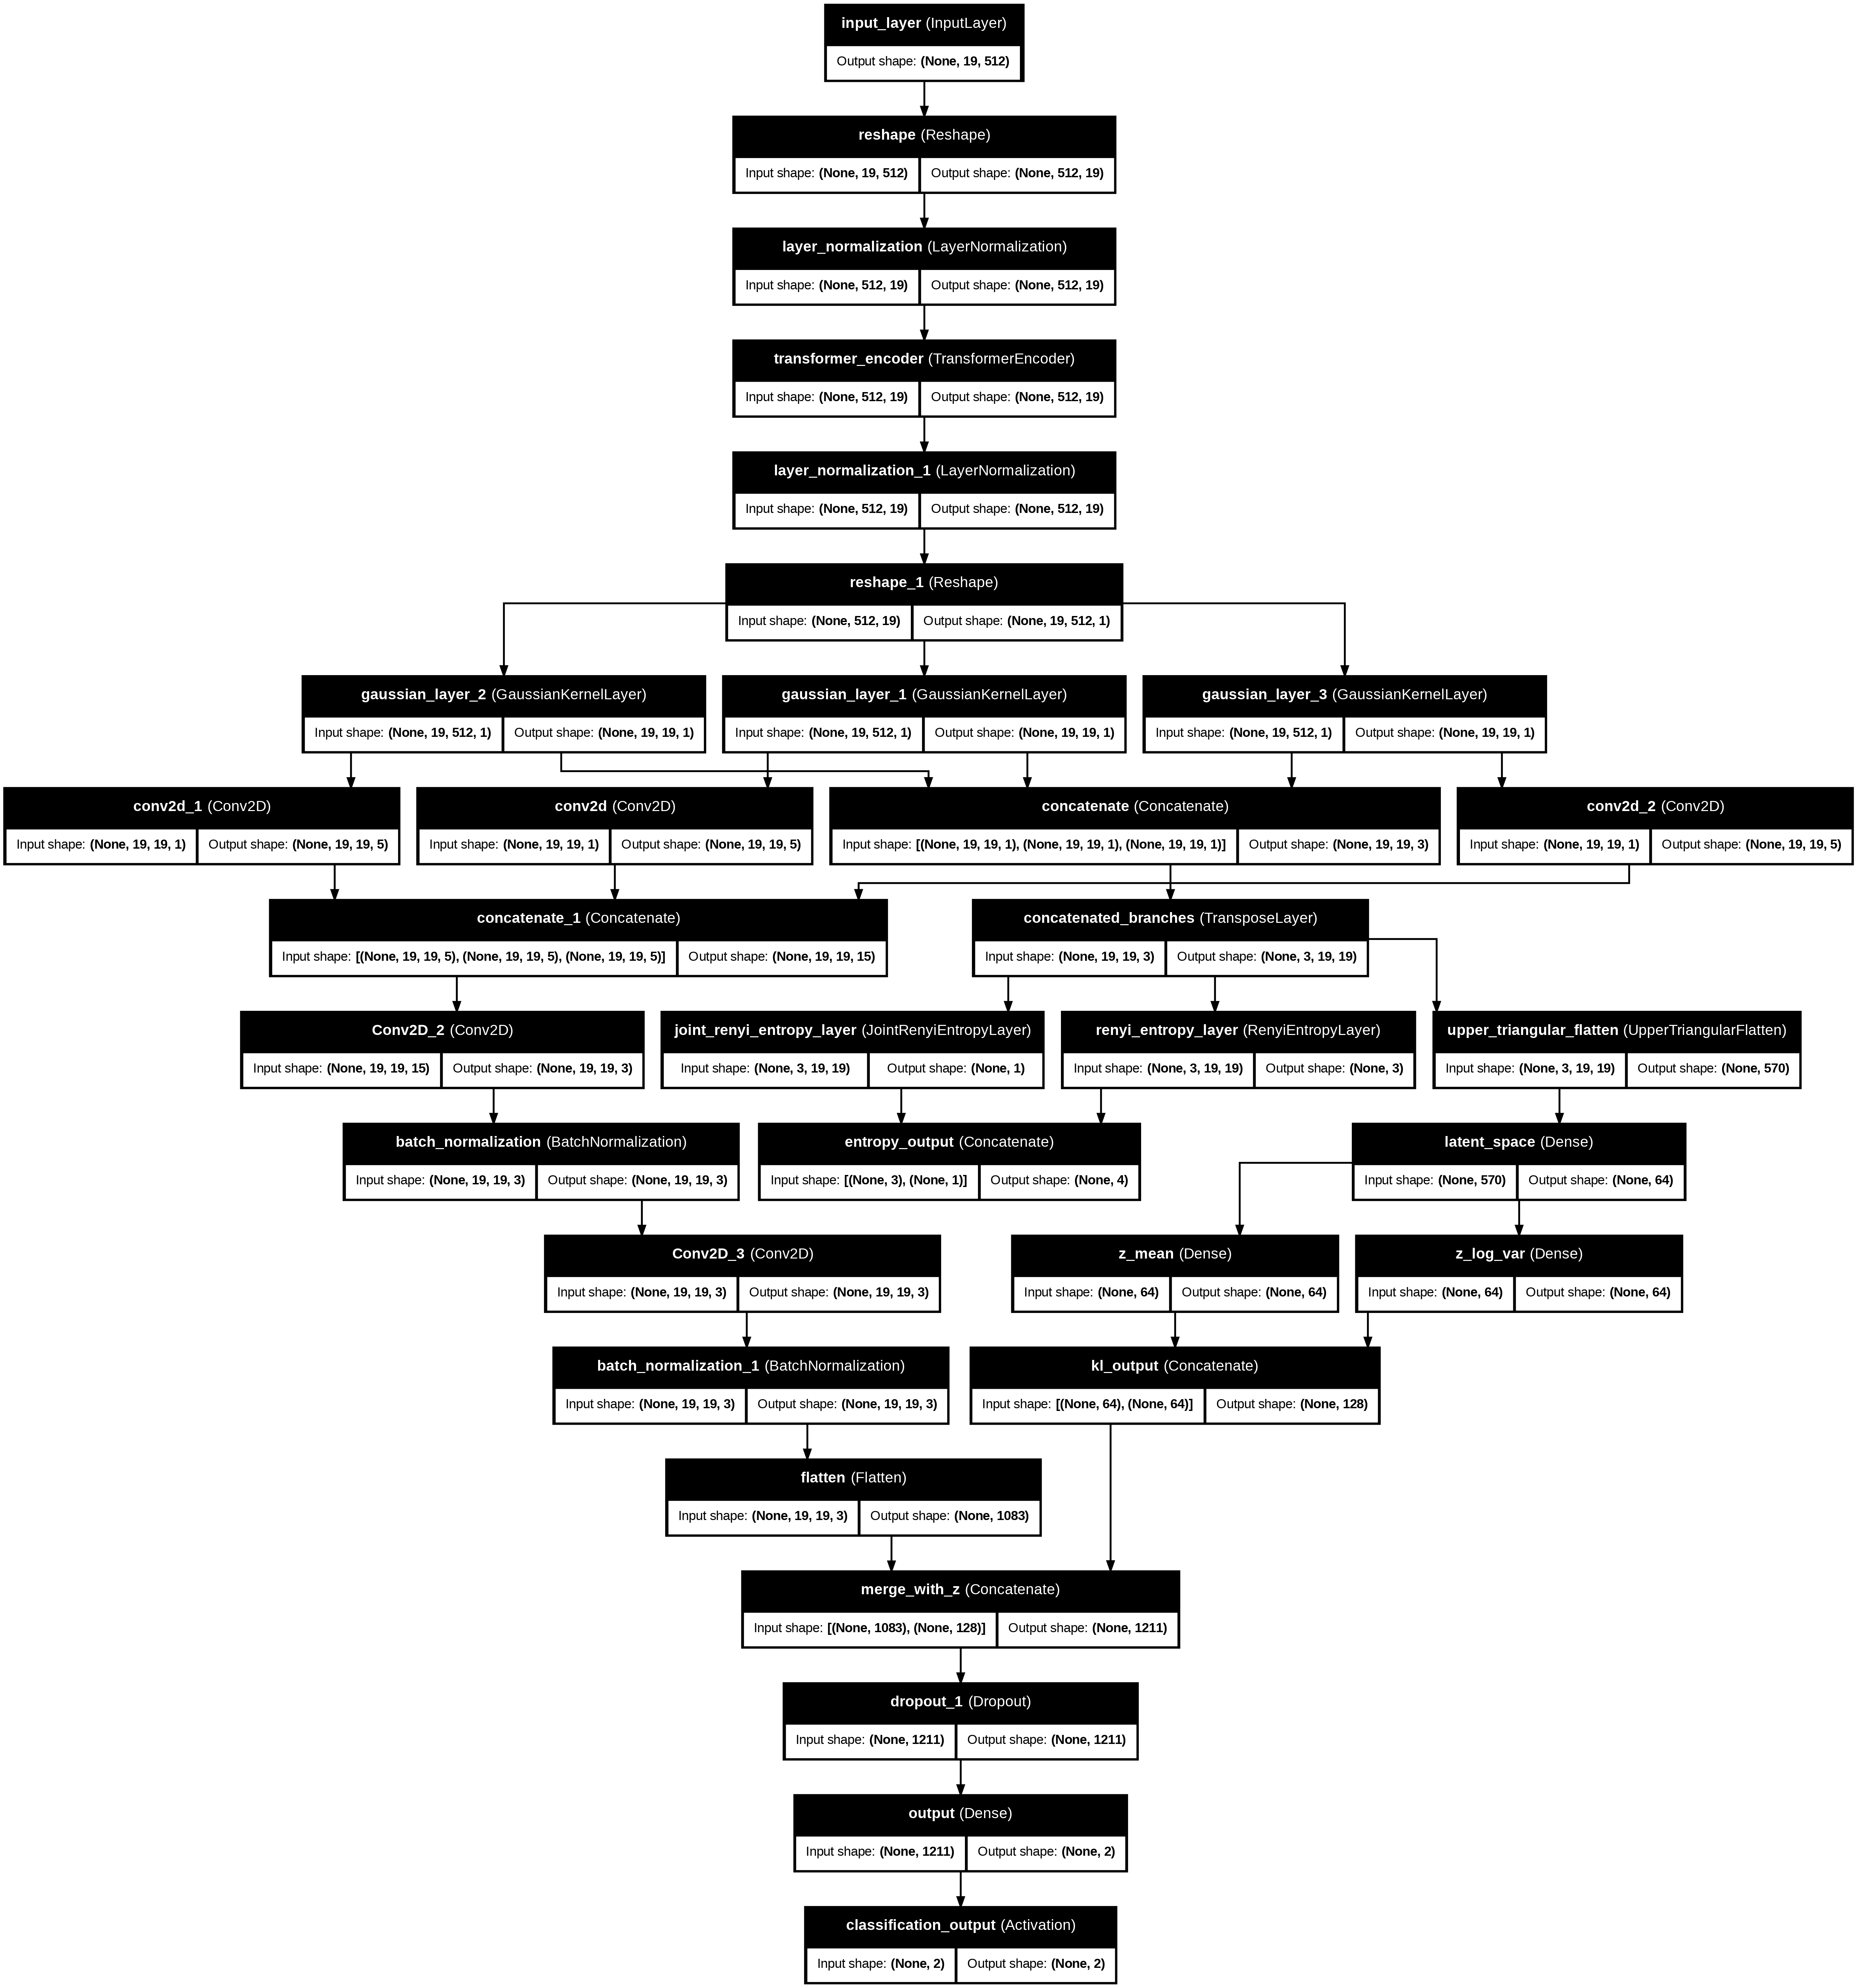

In [9]:
tf.keras.utils.plot_model(model, show_layer_names=True, show_shapes=True)

In [10]:
from sklearn.preprocessing import MinMaxScaler
import umap

def apply_umap(K_triu, labels, y):
    scaler = MinMaxScaler()
    K_triu_norm = scaler.fit_transform(K_triu)
    
    reducer = umap.UMAP(
        n_components=2,
        random_state=42,
        n_jobs=-1,
        min_dist=0.3,       # más dispersión
        n_neighbors=60,     # más estructura global
        metric='euclidean'
    )
    
    data_umap = reducer.fit_transform(K_triu_norm)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 fila, 3 columnas

    colores = [labels, np.argmax(y, axis=1)]
    for i in range(2):
        sc = axes[i].scatter(
            data_umap[:, 0],
            data_umap[:, 1],
            c=colores[i],
            cmap='nipy_spectral',
            s=15,
            linewidths=0.05
        )

        axes[i].set_xlabel("UMAP 1")
        axes[i].set_ylabel("UMAP 2")
        cbar = plt.colorbar(sc, shrink=0.6, ax=axes[i])
        
        
    axes[0].set_title("UMAP train (0) y test (1)")
    axes[1].set_title("UMAP control (0) y TDAH (1)")
    
    plt.tight_layout()    
    plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, cohen_kappa_score, roc_auc_score, precision_score, recall_score
from tensorflow.keras.callbacks import EarlyStopping
from copy import deepcopy


def plot_training_curves(history, fold):
    stopped_epoch = len(history.history['loss']) - 31

    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.axvline(x=stopped_epoch, color='red', linestyle='--', label='Early Stopping')
    plt.title(f'Fold {fold+1} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    acc_key = 'classification_output_binary_accuracy'
    if acc_key in history.history:
        plt.subplot(1, 2, 2)
        plt.plot(history.history[acc_key], label='Training Accuracy')
        plt.plot(history.history[f'val_{acc_key}'], label='Validation Accuracy')
        plt.axvline(x=stopped_epoch, color='red', linestyle='--', label='Early Stopping')
        plt.title(f'Fold {fold+1} - Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend()
    else:
        print(f"[!] '{acc_key}' not found in training history.")

    plt.tight_layout()
    plt.show()


def evaluate_predictions(y_true, y_pred, sbj_ids):
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro')
    kappa = cohen_kappa_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred, multi_class='ovr', average='macro')

    subject_accuracies = {}
    for subj in set(sbj_ids):
        indices = [i for i, s in enumerate(sbj_ids) if s == subj]
        subject_accuracies[subj] = accuracy_score(y_true[indices], y_pred[indices])

    return {
        'accuracy': acc,
        'recall': recall,
        'precision': precision,
        'kappa': kappa,
        'auc': auc,
        'subject_accuracies': subject_accuracies
    }


def train_L24O_cv(model_fn, X, y, sbjs, model_args=None, compile_args=None, folds=None, model_name=''):
    cv_scores = []

    for fold, (train_subjects, test_subjects) in enumerate(folds):
        compile_args['optimizer'] = tf.keras.optimizers.Adam()
        print(f"\n--- Fold {fold+1}/{len(folds)} | Test subjects: {test_subjects}")

        # --- Indexing ---
        train_idx = [i for i, sbj in enumerate(sbjs) if sbj in train_subjects]
        test_idx = [i for i, sbj in enumerate(sbjs) if sbj in test_subjects]

        if model_name == 'spatio_temporal':
            freq, temp, spat = X
            X_train = [freq[train_idx], temp[train_idx], spat[train_idx]]
            X_test = [freq[test_idx], temp[test_idx], spat[test_idx]]
        else:
            X_train, X_test = X[train_idx], X[test_idx]

        y_train, y_test = y[train_idx], y[test_idx]

        # --- Model creation and compilation ---
        if model_args is not None:
            model = model_fn(**model_args)
            model.compile(**compile_args)
        else:
            model = model_fn  # Already compiled externally

        # --- Training ---
        early_stopping = EarlyStopping(
            monitor='val_loss', patience=30, min_delta=0.01, restore_best_weights=True
        )

        history = model.fit(
            X_train, [y_train]*4,
            validation_data=(X_test, [y_test]*4),
            epochs=100,
            batch_size=16,
            verbose=0,
            callbacks=[early_stopping]
        )

        #plot_training_curves(history, fold)

        # --- Prediction and latent analysis ---
        if model_name == 'GMRRNet':
            y_pred_probs = model.predict(X_test, verbose=0)[0]
            kernels_train = model.predict(X_train, verbose=0)[-1]
            kernels_test = model.predict(X_test, verbose=0)[-1]

            # Upper triangular extraction
            N_train, G, C, _ = kernels_train.shape
            N_test = kernels_test.shape[0]
            triu_idx = np.triu_indices(C)

            kernels_train_flat = kernels_train[:, :, triu_idx[0], triu_idx[1]].reshape(N_train, -1)
            kernels_test_flat = kernels_test[:, :, triu_idx[0], triu_idx[1]].reshape(N_test, -1)

            kernels = np.concatenate([kernels_train_flat, kernels_test_flat], axis=0)
            labels = np.concatenate([np.zeros(N_train), np.ones(N_test)])
            #apply_umap(kernels, labels, np.concatenate([y_train, y_test]))
        else:
            y_pred_probs = model.predict(X_test, verbose=0)

        # --- Evaluation ---
        y_pred = np.argmax(y_pred_probs, axis=1) if y_pred_probs.ndim > 1 else (y_pred_probs > 0.5).astype(int)
        y_true = y_test if y_test.ndim == 1 else np.argmax(y_test, axis=1)

        test_sbjs = [sbjs[i] for i in test_idx]
        metrics = evaluate_predictions(y_true, y_pred, test_sbjs)

        print(f"Fold {fold+1} metrics:", metrics)
        cv_scores.append(metrics)

    return cv_scores


In [12]:
model_name = 'GMRRNet'


compile_args = {
    'loss': [
        NormalizedBinaryCrossentropy(name="NormalizedBinaryCrossentropy"),
        RenyiMutualInformation(C=tf.cast(19.0, tf.float64), name='MutualInfo'),
        KL_divergence(name="KL_divergence"),
        None  # Para la rama de kernels, sin pérdida
    ],
    'loss_weights': [lambda_1, lambda_2, lambda_3, 0],
    'optimizer': tf.keras.optimizers.Adam(),
    'metrics': [['binary_accuracy'], [None], [None], [None]],
    #'run_eagerly':True
}

results = {}

for i in range(10):
    result = train_L24O_cv(GMRRNet, X, y, sbjs, model_args, compile_args, folds, model_name)
    results[i] = result


--- Fold 1/5 | Test subjects: ['v28p', 'v274', 'v1p', 'v231', 'v22p', 'v29p', 'v206', 'v238', 'v31p', 'v35p', 'v177', 'v200', 'v112', 'v113', 'v48p', 'v140', 'v131', 'v125', 'v55p', 'v143', 'v43p', 'v305', 'v134', 'v114']


I0000 00:00:1751554327.360627      68 service.cc:148] XLA service 0x795a64002c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751554327.361412      68 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1751554328.641658      68 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1751554335.795184      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Fold 1 metrics: {'accuracy': 0.696636925188744, 'recall': 0.6966455586267313, 'precision': 0.6963119821470307, 'kappa': 0.3928090574121357, 'auc': 0.6966455586267313, 'subject_accuracies': {'v134': 0.803921568627451, 'v1p': 0.15217391304347827, 'v48p': 1.0, 'v143': 0.0847457627118644, 'v140': 0.0, 'v206': 1.0, 'v125': 0.3559322033898305, 'v231': 1.0, 'v28p': 0.0, 'v200': 1.0, 'v131': 0.921875, 'v112': 0.9836065573770492, 'v43p': 1.0, 'v113': 1.0, 'v29p': 0.967741935483871, 'v35p': 1.0, 'v238': 0.7837837837837838, 'v274': 1.0, 'v31p': 1.0, 'v114': 1.0, 'v22p': 0.021739130434782608, 'v55p': 0.6851851851851852, 'v177': 0.53125, 'v305': 0.7674418604651163}}

--- Fold 2/5 | Test subjects: ['v18p', 'v39p', 'v234', 'v32p', 'v190', 'v6p', 'v254', 'v204', 'v24p', 'v183', 'v246', 'v219', 'v298', 'v41p', 'v47p', 'v308', 'v52p', 'v300', 'v59p', 'v299', 'v302', 'v51p', 'v109', 'v127']
Fold 2 metrics: {'accuracy': 0.7883693045563549, 'recall': 0.7928891330866418, 'precision': 0.7889537190938214, 'ka

In [13]:
import numpy as np

for i in range(10):
    result = results[i]
    accs = []
    for r in result:
        accs.append(r['accuracy'])
    
    print(i, '->', np.mean(accs))

0 -> 0.812079616733973
1 -> 0.8658007822907375
2 -> 0.8290637260244988
3 -> 0.8226653332808329
4 -> 0.8408051777551571
5 -> 0.8290957918355643
6 -> 0.8243215665927475
7 -> 0.7695893478153621
8 -> 0.7831682016144252
9 -> 0.8599808236564467


In [14]:
import pickle

with open('results.pkl', 'wb') as f:
    pickle.dump(results, f)